First code is for creating the Structural Causal Model based on the variables of the dataset


C:\Users\irene\AppData\Local\Temp\ipykernel_16648\3995172923.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


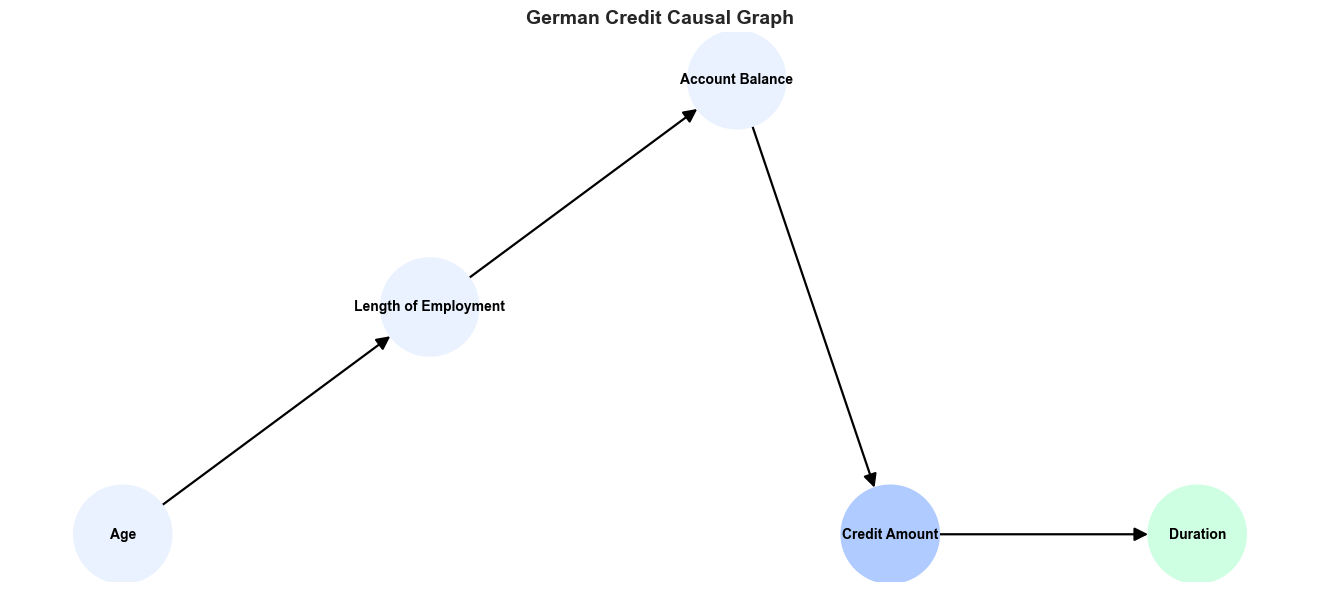

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Create directed graph
G = nx.DiGraph()

# Add causal edges
edges = [
    ("Age", "Length of Employment"),
    ("Length of Employment", "Account Balance"),
    ("Account Balance", "Credit Amount"),
    ("Credit Amount", "Duration")
]
G.add_edges_from(edges)

# Manual positions for a clean layout
pos = {
    "Age": (0, 1),
    "Length of Employment": (2, 1.5),
    "Number of Credits": (2, 0.5),
    "Account Balance": (4, 2),
    "Credit Amount": (5, 1),
    "Duration": (7, 1)
}

# Node colors
node_colors = []
for node in G.nodes():
    if node == "Credit Amount":
        node_colors.append("#AFCBFF")   # highlight main node
    elif node == "Duration":
        node_colors.append("#CFFFE2")
    else:
        node_colors.append("#EAF2FF")

plt.figure(figsize=(13, 5.5))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    node_color=node_colors,
    font_size=10,
    font_weight="bold",
    arrows=True,
    arrowsize=20,
    width=1.6
)

plt.title("German Credit Causal Graph", fontsize=14, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()

## Explanation of variables and casual relations  - Causal Graph Variable Justification (German Credit)

The graph contains the following causal relationships:

- Age → Length of Employment
- Age → Number of Credits
- Length of Employment → Account Balance
- Length of Employment → Credit Amount
- Account Balance → Credit Amount
- Number of Credits → Credit Amount
- Credit Amount → Duration

---

## 1. Age
**Age** acts as the upstream demographic variable in the graph.

It is treated as a root cause because age naturally precedes:
- employment history
- financial experience
- credit history
- long-term relationship with the bank

Older individuals have had more time to accumulate job experience and previous credit products.

---

## 2. Age → Length of Employment
This relationship assumes that older applicants are more likely to have spent longer in their current job.

This is causally plausible because:
- age comes before employment duration in time
- younger applicants cannot realistically have very long job histories
- employment stability generally increases over the life cycle

This edge captures the idea that life stage influences job stability.

---

## 3. Age → Number of Credits
This edge represents the assumption that older customers have had more time to:
- open financial products
- take previous loans
- repay older loans
- build trust with the bank

Therefore, age causally influences the number of previous credits at the bank.

---

## 4. Length of Employment
This variable reflects job stability and income reliability.

Longer employment duration is often associated with:
- stable salary inflow
- lower perceived default risk
- stronger financial predictability

It therefore acts as an important intermediate financial node.

---

## 5. Length of Employment → Account Balance
Stable employment can increase available account balance through:
- regular income
- savings accumulation
- reduced financial volatility

This relationship captures the idea that job stability influences liquidity.

---

## 6. Length of Employment → Credit Amount
Applicants with longer employment duration are often more likely to qualify for larger loans.

This edge is justified because employment duration signals:
- stable income
- lower risk
- higher repayment capacity

Thus, employment stability can influence the feasible loan amount.

---

## 7. Account Balance
This variable represents short-term liquidity and available funds.

Higher balances indicate:
- stronger immediate solvency
- financial buffers
- savings discipline

This is a key variable in determining feasible credit levels.

---

## 8. Account Balance → Credit Amount
A stronger account balance may allow larger credit amounts because it signals:
- lower liquidity risk
- better repayment confidence
- stronger financial health

This edge captures the idea that **available liquidity supports larger borrowing capacity**.

---

## 9. Number of Credits
This variable reflects **existing or previous credit exposure at the same bank**.

It captures:
- prior debt commitments
- historical customer relationship
- previous repayment behavior

This makes it highly relevant to future loan decisions.

---

## 10. Number of Credits → Credit Amount
The number of existing credits can influence feasible borrowing because it reflects:
- current debt load
- trust built with the bank
- historical repayment success

This creates a **multi-parent causal structure** for Credit Amount.

---

## 11. Credit Amount
This is the **central financial decision node** in the graph.

It is influenced by:
- employment stability
- liquidity
- previous credit exposure

This makes it the key **multi-parent node** in the causal structure.

---

## 12. Credit Amount → Duration
This relationship assumes that larger loans generally require longer repayment periods.

This is financially realistic because:
- larger loans increase repayment burden
- banks often spread larger amounts over longer horizons
- longer duration reduces monthly installments

This edge captures the loan structure dependency between amount and repayment horizon.

---

## Summary
The graph combines:
- one demographic root variable (**Age**)
- three intermediate financial stability variables
- one central multi-parent decision node (**Credit Amount**)
- one downstream repayment node (**Duration**)

This creates a compact causal structure that is sufficiently expressive for evaluating whether **causal constraints improve the stability of counterfactual explanations**.